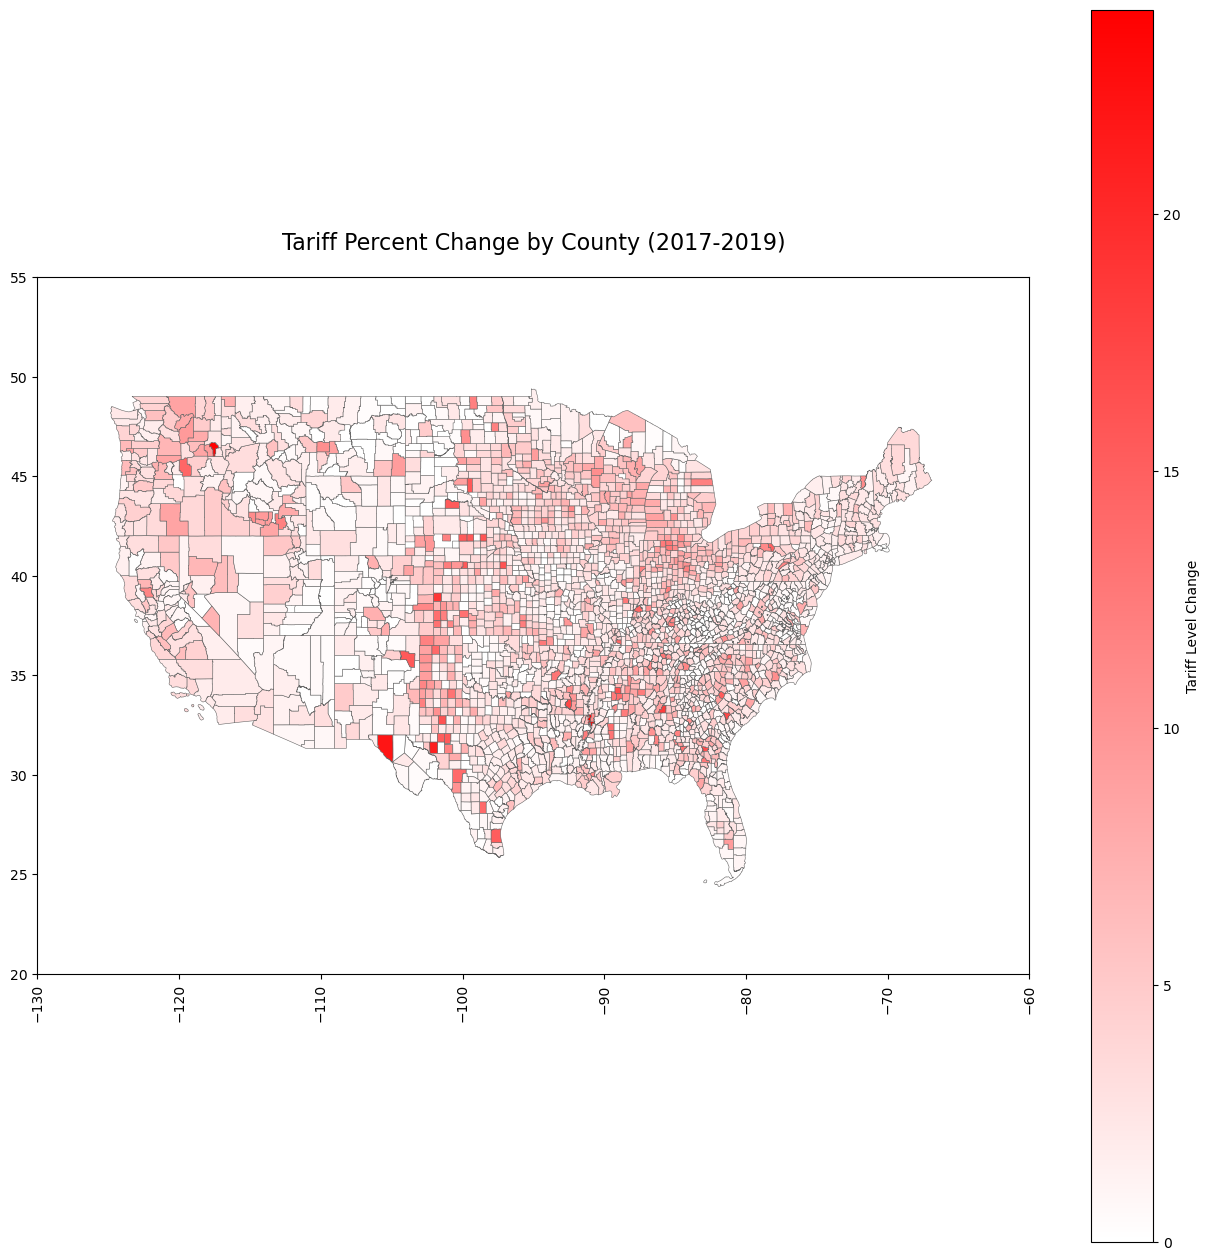

In [12]:
#!/usr/bin/env python
# coding: utf-8

import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import os
from matplotlib.colors import LinearSegmentedColormap

# Read tariff data
tariffs = pd.read_csv('../Data/ustariffs-by-county.csv')

# Remove columns except graphing data
tariffs_clean = tariffs.drop(columns=['Unnamed: 0','emplvl_2017', 'fips', 'total_employment', 'int_area_fips',
       '2017_income', '2017_population', 'total_imp_pc', 'china_imp_pc'])

# Filter for years wanted
tariffs_clean['time'] = pd.to_datetime(tariffs_clean['time'])
tariffs_clean = tariffs_clean[(tariffs_clean['time'].dt.year >= 2017) & (tariffs_clean['time'].dt.year <= 2019)]

# Clean area_fips
tariffs_clean['area_fips'] = tariffs_clean['area_fips'].astype(str).str.zfill(5)

# Filter out special FIPS codes
tariffs_clean = tariffs_clean[~tariffs_clean['area_fips'].astype(str).str.endswith('999')]

# Remove first time period and drop state column if it exists
tariffs_clean = tariffs_clean[tariffs_clean['time'] != '2017-01-01 00:00:00']
if 'state' in tariffs_clean.columns:
    tariffs_clean = tariffs_clean.drop('state', axis=1)
tariffs_clean = tariffs_clean.reset_index(drop=True)

# Pivot the data
tariffs_clean_pivoted = tariffs_clean.pivot(index='area_fips', columns='time', values='tariff')
tariffs_clean_pivoted = tariffs_clean_pivoted.reset_index()

# Calculate tariff change (last column - second column, since first is area_fips)
tariffs_clean_pivoted['tariff_change'] = tariffs_clean_pivoted.iloc[:,-1] - tariffs_clean_pivoted.iloc[:,1]

# Remove NA values
tariffs_clean_pivoted = tariffs_clean_pivoted.dropna()

# Read the county shapefile
county = gpd.read_file(os.getcwd()+ '/tl_2019_us_county')
map_tariffs = county.merge(tariffs_clean_pivoted, left_on='GEOID', right_on='area_fips')

# Set up the figure and axis
fig, ax = plt.subplots(1, figsize=(16, 16))
plt.xticks(rotation=90)

# Create a custom white to red colormap
white_red = LinearSegmentedColormap.from_list('white_red', ['white', 'red'])

# Use a standard normalization
norm = plt.Normalize(vmin=map_tariffs["tariff_change"].min(), vmax=map_tariffs["tariff_change"].max())

# Plot the data using the custom white-to-red colormap
map_tariffs.plot(column="tariff_change", 
                cmap=white_red, 
                linewidth=0.4, 
                ax=ax, 
                edgecolor=".4", 
                legend=False, 
                norm=norm)

# Set x and y limits to focus on mainland US
ax.set_xlim(-130, -60)
ax.set_ylim(20, 55)

# Create the colorbar
sm = plt.cm.ScalarMappable(cmap=white_red, norm=norm)
sm._A = []  # Empty array for the ScalarMappable
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Tariff Level Change')

plt.title('Tariff Percent Change by County (2017-2019)', fontsize=16, pad=20)

# Create output path in Images folder
output_path = os.path.join('Images', 'Heat_Map_tariff.png')

# Save the plot with high resolution
plt.savefig(output_path, 
            dpi=300,
            bbox_inches='tight',
            pad_inches=0.1)

plt.savefig('../images/tariff_change_heatmap.png', 
            dpi=300,              # Higher resolution
            bbox_inches='tight',  # Ensures no labels are cut off
            facecolor='white',    # White background
            format='png')         # File format

plt.show()